In [ ]:
PART 1: DATA CLEANING

In [ ]:
## Load the Data

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/sales_data.csv")

df.head()

,transaction_id,datum,store,province,kategorie,bedrag,quantity,customer_id,payment_method
0,TXN-000001,12-06-2024,NaN,KZN,beauty,R1193.12,2,CUST-00423,EFT
1,TXN-000002,12 Oct 2024,Mall of the North,Limpopo Province,F&B,R649,1,CUST-01439,Card
2,TXN-000003,14/10/2024,NaN,KwaZulu-Natal,Clothing,R1475.61,1,CUST-01798,Mobile Money
3,TXN-000004,18 Jul 2024,Mall of North,Limpopo Province,Home,R4101.35,2,CUST-00012,Card
4,TXN-000005,02/08/2024,eastgate,Gauteng Province,Home & Living,R3381.59,3,CUST-00894,Card


In [ ]:
I used `df.head()` to preview the first few rows and understand what the raw dataset looks like.

In [30]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(5132, 9)

Column names:
Index(['transaction_id', 'datum', 'store', 'province', 'kategorie', 'bedrag',
       'quantity', 'customer_id', 'payment_method'],
      dtype='str')

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 5132 entries, 0 to 5131
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   transaction_id  5132 non-null   str  
 1   datum           5132 non-null   str  
 2   store           4372 non-null   str  
 3   province        4880 non-null   str  
 4   kategorie       5132 non-null   str  
 5   bedrag          5132 non-null   str  
 6   quantity        5132 non-null   int64
 7   customer_id     4985 non-null   str  
 8   payment_method  5132 non-null   str  
dtypes: int64(1), str(8)
memory usage: 361.0 KB

Missing values:
transaction_id      0
datum               0
store             760
province          252
kategorie           0
bedrag              0
quantity            0
cust

In [ ]:
# This first check shows me the structure of the data and whether there are missing values or columns that need cleaning.

In [31]:
clean_df = df.copy()

clean_df = clean_df.rename(columns={
    "datum": "transaction_date",
    "kategorie": "category",
    "bedrag": "revenue"
})

clean_df.columns = clean_df.columns.str.strip().str.lower()

clean_df.head()

,transaction_id,transaction_date,store,province,category,revenue,quantity,customer_id,payment_method
0,TXN-000001,12-06-2024,NaN,KZN,beauty,R1193.12,2,CUST-00423,EFT
1,TXN-000002,12 Oct 2024,Mall of the North,Limpopo Province,F&B,R649,1,CUST-01439,Card
2,TXN-000003,14/10/2024,NaN,KwaZulu-Natal,Clothing,R1475.61,1,CUST-01798,Mobile Money
3,TXN-000004,18 Jul 2024,Mall of North,Limpopo Province,Home,R4101.35,2,CUST-00012,Card
4,TXN-000005,02/08/2024,eastgate,Gauteng Province,Home & Living,R3381.59,3,CUST-00894,Card


In [ ]:
# I renamed 

In [60]:
# Clean store names
clean_df["store"] = clean_df["store"].fillna("Online")
clean_df["store"] = clean_df["store"].astype(str).str.strip().str.title()

clean_df["store"] = clean_df["store"].replace({
    "": "Online",
    "Nan": "Online",
    "Online Store": "Online",
    "Web": "Online",

    "Baywest": "Baywest Mall",
    "Bay West Mall": "Baywest Mall",

    "Sandton City Mall": "Sandton City",

    "Va Waterfront": "V&A Waterfront",
    "V And A Waterfront": "V&A Waterfront",
    "V&A": "V&A Waterfront",

    "Gateway": "Gateway Umhlanga",
    "Gateway Mall Umhlanga": "Gateway Umhlanga",

    "Menlyn": "Menlyn Park",
    "Menlyn Park Mall": "Menlyn Park",

    "Canal Walk Mall": "Canal Walk",

    "Eastgate Mall": "Eastgate",
    "East Gate": "Eastgate",

    "Mall Of North": "Mall of the North",
    "Mall Of The North": "Mall of the North",
    "Motn": "Mall of the North"
})

clean_df["store"].value_counts()

store
Online               1107
Eastgate              536
Menlyn Park           532
V&A Waterfront        530
Sandton City          528
Canal Walk            524
Baywest Mall          524
Gateway Umhlanga      514
Mall of the North     337
Name: count, dtype: int64

In [61]:
clean_df["province"] = clean_df["province"].fillna("Unknown")
clean_df["province"] = clean_df["province"].astype(str).str.strip().str.title()

clean_df["province"] = clean_df["province"].replace({
    "": "Unknown",
    "Nan": "Unknown",
    "Gp": "Gauteng",
    "Gauteng Province": "Gauteng",
    "Wc": "Western Cape",
    "W. Cape": "Western Cape",
    "Western Cape Province": "Western Cape",
    "Kzn": "KwaZulu-Natal",
    "Kwazulu Natal": "KwaZulu-Natal",
    "Kwazulu-Natal": "KwaZulu-Natal",
    "Ec": "Eastern Cape",
    "E. Cape": "Eastern Cape",
    "Lp": "Limpopo",
    "Limpopo Province": "Limpopo"
})

clean_df["category"] = clean_df["category"].fillna("Unknown")
clean_df["category"] = clean_df["category"].astype(str).str.strip().str.title()

clean_df["category"] = clean_df["category"].replace({
    "Elec.": "Electronics",
    "Electronic": "Electronics",
    "Tech": "Electronics",
    "Clothes": "Clothing",
    "Apparel": "Clothing",
    "Home": "Home & Living",
    "Home And Living": "Home & Living",
    "H&L": "Home & Living",
    "Beauty & Health": "Beauty",
    "Cosmetics": "Beauty",
    "Food": "Food & Beverage",
    "Food And Beverage": "Food & Beverage",
    "F&B": "Food & Beverage",
    "Sport": "Sports",
    "Sports & Outdoors": "Sports"
})

print("Province values:")
print(clean_df["province"].value_counts())

print("\nCategory values:")
print(clean_df["category"].value_counts())

Province values:
province
Gauteng          1747
Western Cape     1224
KwaZulu-Natal     696
Eastern Cape      696
Limpopo           517
Unknown           252
Name: count, dtype: int64

Category values:
category
Beauty             904
Sports             870
Food & Beverage    847
Clothing           842
Home & Living      835
Electronics        834
Name: count, dtype: int64


In [ ]:
#This makes the province and category analysis more accurate 

In [62]:
clean_df["revenue"] = clean_df["revenue"].astype(str)

clean_df["revenue"] = (
    clean_df["revenue"]
    .str.replace("R", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace("(", "-", regex=False)
    .str.replace(")", "", regex=False)
    .str.strip()
)

clean_df["revenue"] = pd.to_numeric(clean_df["revenue"], errors="coerce")

print("Missing revenue values after conversion:")
print(clean_df["revenue"].isna().sum())

clean_df["revenue"].head()

Missing revenue values after conversion:
0


0    1193.12
1     649.00
2    1475.61
3    4101.35
4    3381.59
Name: revenue, dtype: float64

In [63]:
clean_df["original_transaction_date"] = clean_df["transaction_date"]

clean_df["transaction_date"] = pd.to_datetime(
    clean_df["original_transaction_date"],
    errors="coerce",
    format="mixed",
    dayfirst=True
)

clean_df["month"] = clean_df["transaction_date"].dt.to_period("M")

print("Missing/invalid dates after conversion:")
print(clean_df["transaction_date"].isna().sum())

clean_df[["original_transaction_date", "transaction_date", "month"]].head(5)

Missing/invalid dates after conversion:
0


,original_transaction_date,transaction_date,month
0,2024-06-12,2024-06-12,2024-06
1,2024-10-12,2024-10-12,2024-10
2,2024-10-14,2024-10-14,2024-10
3,2024-07-18,2024-07-18,2024-07
4,2024-08-02,2024-08-02,2024-08


In [64]:
print("Duplicate rows:")
print(clean_df.duplicated().sum())

print("\nDuplicate transaction IDs:")
print(clean_df["transaction_id"].duplicated().sum())

Duplicate rows:
0

Duplicate transaction IDs:
0


In [65]:
returns = clean_df[clean_df["revenue"] < 0]
sales = clean_df[clean_df["revenue"] >= 0]

print("Return rows:")
print(returns.shape[0])

print("\nSales rows:")
print(sales.shape[0])

returns.head()

Return rows:
376

Sales rows:
4756


,transaction_id,transaction_date,store,province,category,revenue,quantity,customer_id,payment_method,original_transaction_date,month
18,TXN-000019,2024-10-21,Baywest Mall,Eastern Cape,Food & Beverage,-2224.27,2,CUST-00765,Mobile Money,2024-10-21,2024-10
41,TXN-000042,2024-02-09,Eastgate,Gauteng,Food & Beverage,-2494.19,1,CUST-00110,EFT,2024-02-09,2024-02
62,TXN-000063,2024-07-11,Eastgate,Gauteng,Sports,-558.08,5,CUST-01014,Cash,2024-07-11,2024-07
70,TXN-000071,2024-03-14,Sandton City,Gauteng,Sports,-4134.98,1,CUST-01020,Cash,2024-03-14,2024-03
77,TXN-000078,2024-10-14,Canal Walk,Western Cape,Clothing,-719.81,5,CUST-01539,Card,2024-10-14,2024-10


In [ ]:
PART 2: EXPLORATORY ANALYSIS

In [66]:
# 1. Top 5 stores by revenue

top_5_stores = (
    sales.groupby("store")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_stores

store
Online          3153830.82
Menlyn Park     1488262.62
Canal Walk      1471369.84
Eastgate        1440108.38
Baywest Mall    1372787.67
Name: revenue, dtype: float64

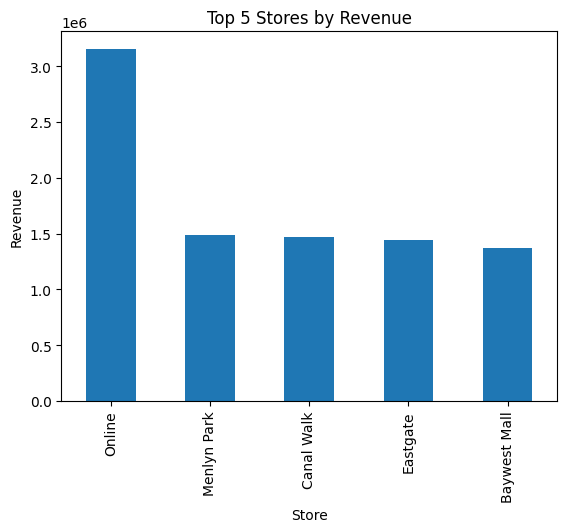

In [40]:
top_5_stores.plot(kind="bar", title="Top 5 Stores by Revenue")

plt.xlabel("Store")
plt.ylabel("Revenue")
plt.show()

In [67]:
# 2. Best product category by revenue

category_revenue = (
    sales.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Electronics        6225153.61
Home & Living      3026056.79
Sports             2082440.80
Clothing           1439227.33
Beauty              859418.44
Food & Beverage     335377.45
Name: revenue, dtype: float64

In [68]:
best_category = category_revenue.idxmax()

print("Best product category:", best_category)

Best product category: Electronics


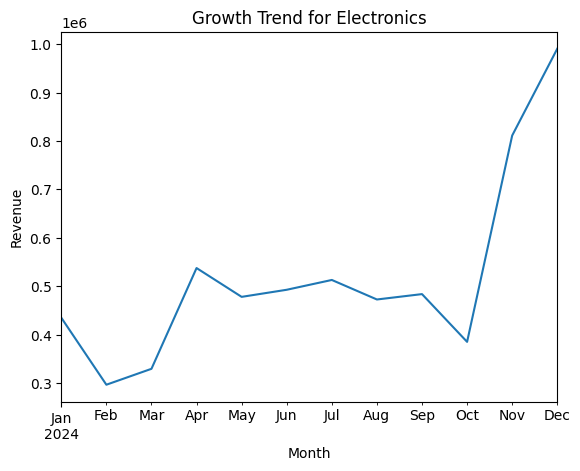

In [69]:
best_category_trend.plot(kind="line", title=f"Growth Trend for {best_category}")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [70]:
# 3. Seasonal pattern

monthly_revenue = (
    sales.groupby("month")["revenue"]
    .sum()
)

monthly_revenue

month
2024-01     844076.37
2024-02     832787.32
2024-03     799181.88
2024-04    1122257.04
2024-05    1001324.15
2024-06    1089937.80
2024-07    1125960.60
2024-08    1033817.35
2024-09    1101250.09
2024-10    1134176.84
2024-11    1667602.71
2024-12    2215302.27
Freq: M, Name: revenue, dtype: float64

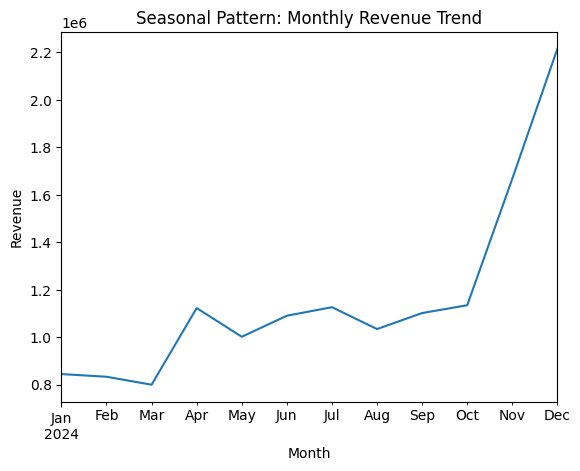

In [71]:
monthly_revenue.plot(kind="line", title="Seasonal Pattern: Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [72]:
# 4. Province with highest average transaction value

province_avg_transaction = (
    sales.groupby("province")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

province_avg_transaction

province
Limpopo          3315.305072
Gauteng          2933.978543
Western Cape     2929.591268
KwaZulu-Natal    2899.194181
Eastern Cape     2818.280400
Unknown          2646.022552
Name: revenue, dtype: float64

In [73]:
best_avg_province = province_avg_transaction.idxmax()
best_avg_value = province_avg_transaction.max()

print("Province with highest average transaction value:", best_avg_province)
print("Average transaction value:", best_avg_value)

Province with highest average transaction value: Limpopo
Average transaction value: 3315.3050721649483


In [74]:
# 5. Online vs in-store trend

sales["channel"] = sales["store"].apply(
    lambda store: "Online" if store == "Online" else "In-store"
)

channel_trend = (
    sales.groupby(["month", "channel"])["revenue"]
    .sum()
    .unstack()
)

channel_trend

channel,In-store,Online
month,,
2024-01,652019.17,192057.20
2024-02,668645.73,164141.59
2024-03,663827.73,135354.15
2024-04,902136.57,220120.47
2024-05,775338.88,225985.27
2024-06,829459.81,260477.99
2024-07,975623.64,150336.96
2024-08,763362.24,270455.11
2024-09,822015.66,279234.43


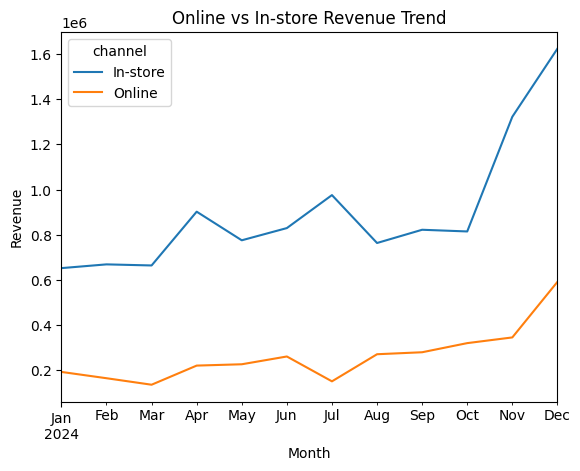

In [75]:
channel_trend.plot(kind="line", title="Online vs In-store Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
PART 3: PREDICTION

In [82]:
# Group revenue by store and month so I can see monthly performance per store

store_monthly_revenue = (
    sales.groupby(["store", "month"])["revenue"]
    .sum()
    .reset_index()
)

store_monthly_revenue.head()

,store,month,revenue
0,Baywest Mall,2024-01,74725.37
1,Baywest Mall,2024-02,77411.06
2,Baywest Mall,2024-03,69416.19
3,Baywest Mall,2024-04,146028.68
4,Baywest Mall,2024-05,116633.58


In [85]:
forecast_next_month = (
    store_monthly_revenue
    .groupby("store")["revenue"]
    .mean()
    .reset_index()
    .rename(columns={"revenue": "predicted_next_month_revenue"})
)

forecast_next_month

,store,predicted_next_month_revenue
0,Baywest Mall,114398.972500
1,Canal Walk,122614.153333
2,Eastgate,120009.031667
3,Gateway Umhlanga,112830.279167
4,Mall of the North,89431.716667
5,Menlyn Park,124021.885000
6,Online,262819.235000
7,Sandton City,111519.968333
8,V&A Waterfront,106327.626667


In [ ]:
PART 4: (Customer summary and Investigation)

In [88]:
customer_summary = (
    sales.groupby("customer_id")
    .agg(
        total_revenue=("revenue", "sum"),
        number_of_transactions=("transaction_id", "count"),
        stores=("store", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

customer_summary.head(10)

,total_revenue,number_of_transactions,stores
customer_id,,,
CUST-00042,101426.77,22,9
CUST-00149,67907.15,13,5
CUST-00142,60856.62,15,6
CUST-00122,58854.87,11,4
CUST-00199,58085.93,15,8
CUST-00073,56318.81,12,6
CUST-00151,55177.75,17,7
CUST-00175,54689.57,13,6
CUST-00146,54659.41,15,8


In [95]:
top_customer = customer_summary.index[0]

top_customer_data = sales[sales["customer_id"] == top_customer]

print("Top customer:", top_customer)
print("Total revenue:", customer_summary.loc[top_customer, "total_revenue"])
print("Number of transactions:", customer_summary.loc[top_customer, "number_of_transactions"])
print("Stores used:", customer_summary.loc[top_customer, "stores"])

top_customer_data[[
    "transaction_id",
    "transaction_date",
    "store",
    "province",
    "category",
    "revenue"
]].sort_values("revenue", ascending=False).head(9)

Top customer: CUST-00042
Total revenue: 101426.77
Number of transactions: 22
Stores used: 9


,transaction_id,transaction_date,store,province,category,revenue
1418,TXN-001419,2024-07-15,Mall of the North,Limpopo,Electronics,14306.19
3472,TXN-003473,2024-07-15,Canal Walk,Western Cape,Electronics,12906.00
1856,TXN-001857,2024-07-15,Sandton City,Gauteng,Electronics,12078.47
3439,TXN-003440,2024-07-15,Gateway Umhlanga,KwaZulu-Natal,Electronics,11558.00
3395,TXN-003396,2024-07-15,Menlyn Park,Gauteng,Electronics,10184.60
2281,TXN-002282,2024-12-08,Baywest Mall,Eastern Cape,Home & Living,7754.74
456,TXN-000457,2024-12-22,Eastgate,Gauteng,Sports,6167.75
3379,TXN-003380,2024-07-04,Eastgate,Gauteng,Home & Living,5476.95
501,TXN-000502,2024-12-01,Online,Limpopo,Electronics,4775.36
